<a href="https://colab.research.google.com/github/agusto027/assign_bit/blob/main/PrimeTrade_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PrimeTrade.ai Hiring Assignment
## Bitcoin Fear & Greed vs Hyperliquid Trader Performance

### Objectives
- Merge sentiment and trading datasets
- Analyze profitability by sentiment
- Compute win rates
- Statistical testing
- Trader segmentation
- Actionable insights

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving fear_greed_index.csv to fear_greed_index (1).csv
Saving historical_data.csv to historical_data (1).csv


In [ ]:
!pip install pandas numpy matplotlib scipy scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.cluster import KMeans

fg = pd.read_csv('fear_greed_index.csv')
tr = pd.read_csv('historical_data.csv')

fg['date']=pd.to_datetime(fg['date'])
tr['date']=pd.to_datetime(tr['Timestamp'],unit='ms').dt.date
tr['date']=pd.to_datetime(tr['date'])

merged = tr.merge(fg[['date','classification']],on='date',how='left')
merged.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed


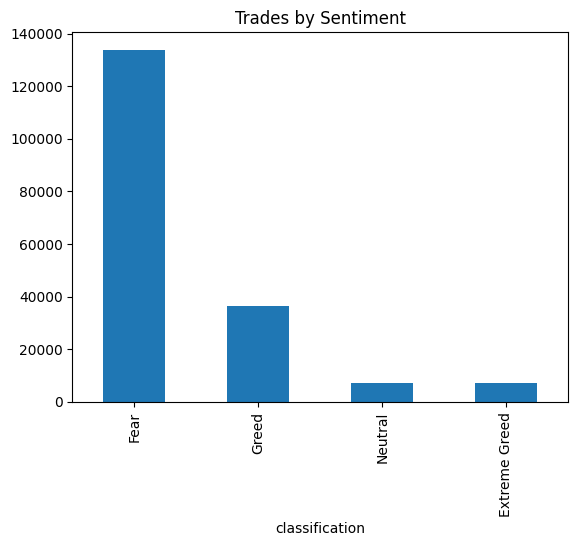

In [ ]:
# Sentiment Distribution
merged['classification'].value_counts().plot(kind='bar')
plt.title('Trades by Sentiment')
plt.show()


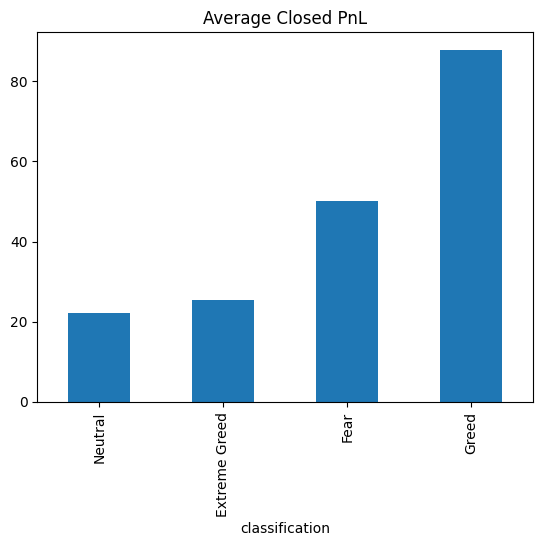

In [ ]:
# Average PnL by Sentiment
merged.groupby('classification')['Closed PnL'].mean().sort_values().plot(kind='bar')
plt.title('Average Closed PnL')
plt.show()


In [ ]:
# Win Rate
merged['win']=(merged['Closed PnL']>0).astype(int)
win_rate=merged.groupby('classification')['win'].mean()*100
print(win_rate)


classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: win, dtype: float64


In [ ]:
# T-Test Fear vs Greed
fear=merged.loc[merged['classification']=='Fear','Closed PnL'].dropna()
greed=merged.loc[merged['classification']=='Greed','Closed PnL'].dropna()
print(ttest_ind(fear,greed,equal_var=False))


TtestResult(statistic=np.float64(-5.804644944972441), pvalue=np.float64(6.489683964771416e-09), df=np.float64(49280.40006430801))


In [ ]:
# Top Traders
top=merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top)


Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


In [ ]:
# Trader Clustering
features=merged.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'Fee':'mean'
}).dropna()

kmeans=KMeans(n_clusters=3, random_state=42, n_init=10)
features['cluster']=kmeans.fit_predict(features)
features.head()


,Closed PnL,Size USD,Fee,cluster
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,1.939579,1
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.374978,0
0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,2.436593,0
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.166657,0
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.959616,0
